In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import polars as pl
import numpy as np

In [2]:
df = pl.read_parquet("../results_static/logs.parquet").to_pandas()

In [3]:
static = df[df["optimizer_id"].str.contains("Static")]

In [4]:
idx = static.groupby(["task_id", "seed", "n_trials"])["trial_value__cost_inc_norm"].idxmin()
vbs = static.loc[idx].reset_index(drop=True)

In [5]:
df["optimizer_id"].unique()

<ArrowStringArray>
[ 'StaticPolicy-1.0', 'StaticPolicy-0.25', 'StaticPolicy-0.75',
           'SAWEI-P',  'StaticPolicy-0.5',  'StaticPolicy-0.0']
Length: 6, dtype: str

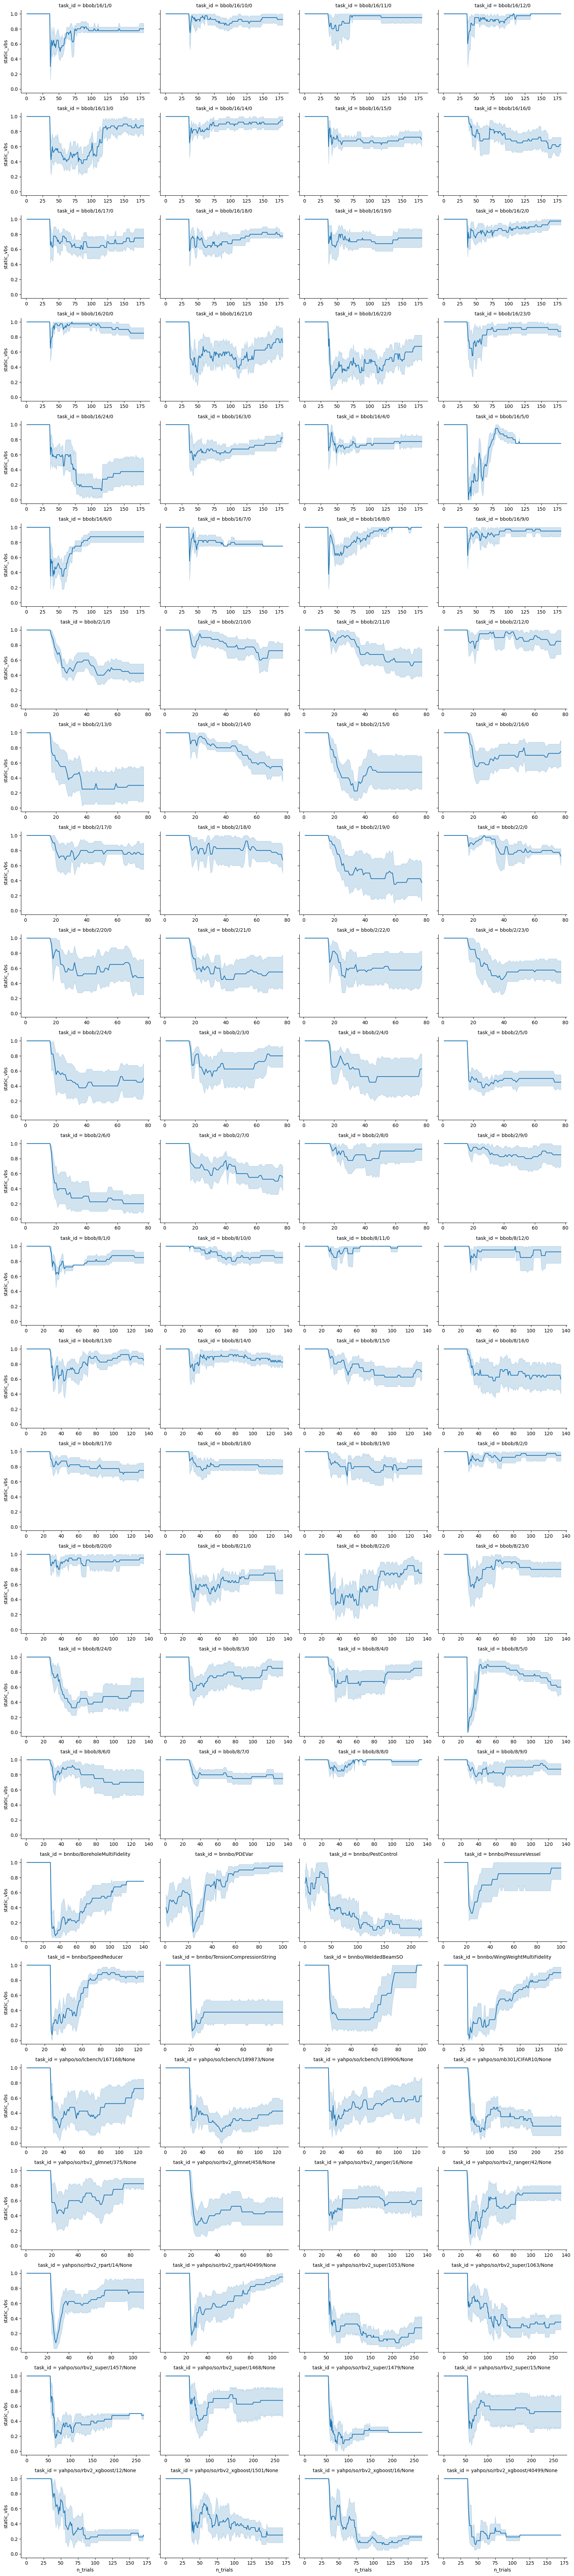

In [6]:
vbs["static_vbs"] = (
    vbs["optimizer_id"]
    .str.split("-")
    .str[1]
    .astype(float)
)

vbs["optimizer_id"] = "StaticVBS"

g = sns.relplot(
    data=vbs,
    kind="line",
    x="n_trials",
    y="static_vbs",
    col="task_id",
    col_wrap=4,
    estimator="mean",
    errorbar=("ci", 95),
    height=3,
    aspect=1.4,
    facet_kws={"sharex": False},
)

plt.show()

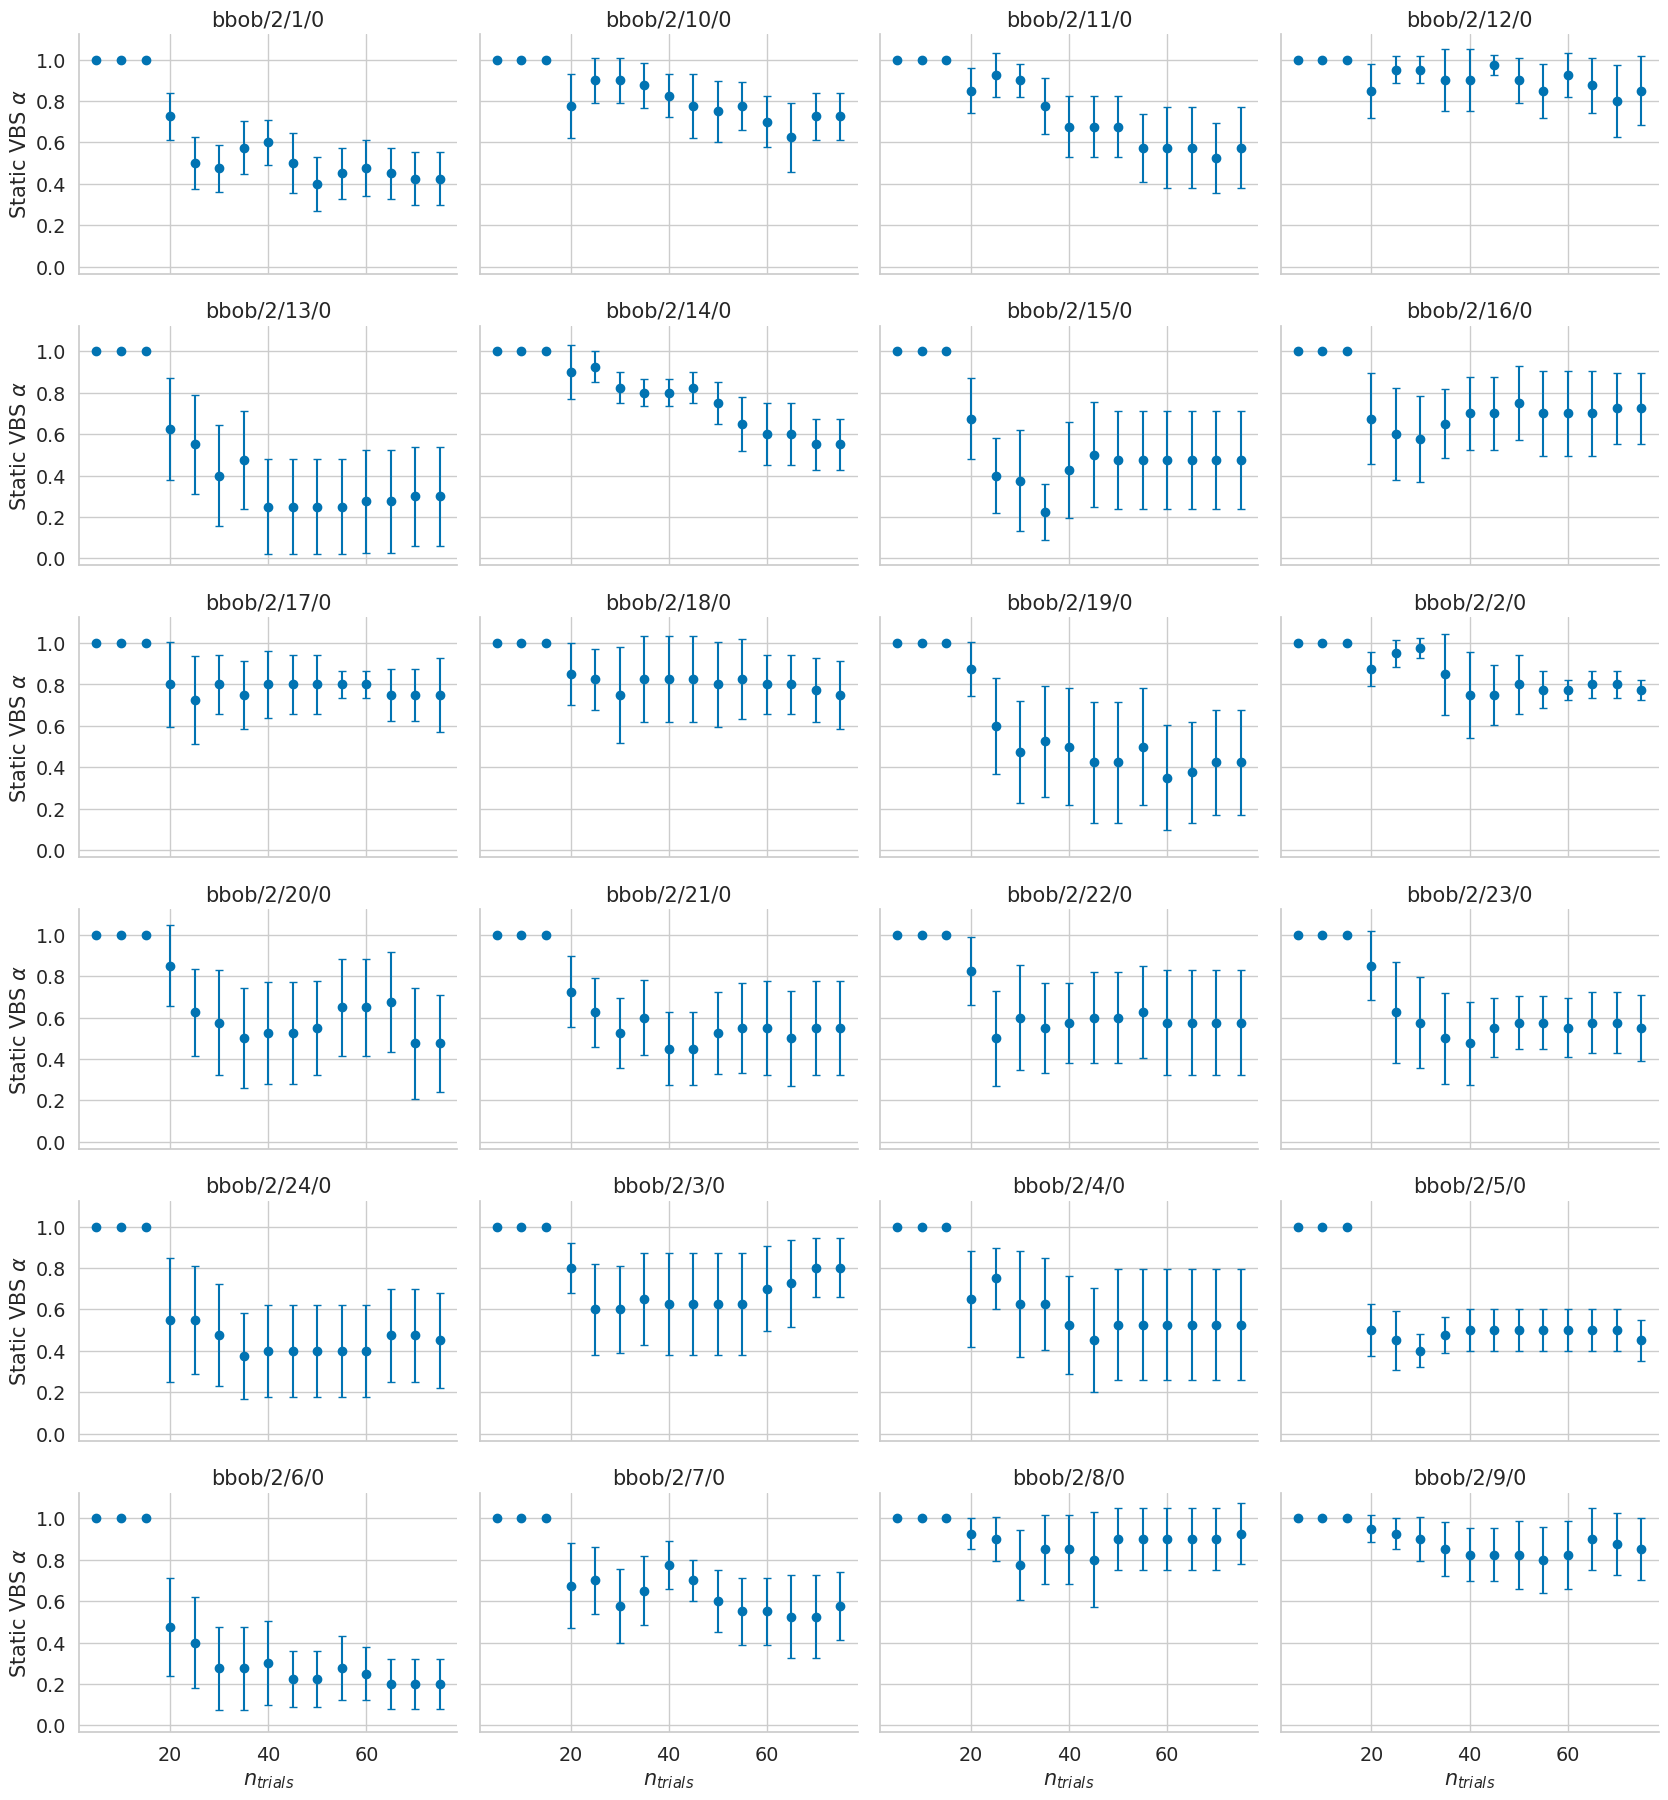

In [7]:
from carps.analysis.utils import setup_seaborn

setup_seaborn(font_scale=1.25)

step = 5

# keep every kth timestep
plot_df = vbs[vbs["n_trials"] % step == 0].copy()

plot_df = plot_df[plot_df["task_id"].str.startswith("bbob/2/")]

stats = (
    plot_df
    .groupby(["task_id", "n_trials"])["static_vbs"]
    .agg(["mean", "std", "count"])
    .reset_index()
)

stats["ci"] = 1.96 * stats["std"] / np.sqrt(stats["count"])

g = sns.FacetGrid(
    stats,
    col="task_id",
    col_wrap=4,
    height=3,
    aspect=1.4,
)

def plot_errorbars(data, **kwargs):
    plt.errorbar(
        data["n_trials"],
        data["mean"],
        yerr=data["ci"],
        fmt="o",
        capsize=3,
    )

g.map_dataframe(plot_errorbars)

g.set_axis_labels(r"$n_{trials}$", r"Static VBS $\alpha$")
g.set_titles("{col_name}")

plt.savefig("figures/results_automl/staticvbs_all.pdf", bbox_inches="tight")
plt.show()

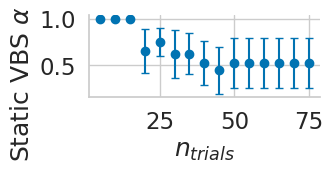

In [8]:
setup_seaborn(font_scale=1.5)

g = sns.FacetGrid(
    stats[stats["task_id"] == "bbob/2/4/0"],
    col="task_id",
    col_wrap=4,
    sharex=False,
    height=2,
    aspect=1.4,
)

def plot_errorbars(data, **kwargs):
    plt.errorbar(
        data["n_trials"],
        data["mean"],
        yerr=data["ci"],
        fmt="o",
        capsize=3,
    )

g.map_dataframe(plot_errorbars)

g.set_axis_labels(r"$n_{trials}$", r"Static VBS $\alpha$        ")
g.set_titles("")

plt.savefig("figures/results_automl/staticvbs_one.pdf", bbox_inches="tight")
plt.show()